In [46]:
import numpy as np
import pandas as pd

df = pd.read_csv("/Users/ali/AliDocuments/AI/python_code_data/data_sets/titanic.csv")
print(df.shape)#boode dade

print(df.info())
print(df.head())
print(df.dtypes)#noe har sotoon

print(df.describe())


(891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                           

In [47]:
missing = pd.DataFrame({
    "nan_count": df.isnull().sum(),
    "percentage": (df.isnull().mean() * 100)
})
print(missing[missing["nan_count"]>0])

          nan_count  percentage
Age             177   19.865320
Cabin           687   77.104377
Embarked          2    0.224467


In [48]:
#indicator age
df['Age_missing'] = df['Age'].isnull().astype(int)

#indicator with other numeric cols
numeric_cols = ['Survived', 'Pclass', 'SibSp', 'Parch', 'Fare']

for col in numeric_cols:
    corr = df['Age_missing'].corr(df[col])
    print(f"{col:10s} →coreleation with missing Age: {corr:+.3f}")

Survived   →coreleation with missing Age: -0.092
Pclass     →coreleation with missing Age: +0.173
SibSp      →coreleation with missing Age: +0.019
Parch      →coreleation with missing Age: -0.124
Fare       →coreleation with missing Age: -0.101


In [49]:
cat_cols = ['Sex', 'Embarked', 'Pclass']

for col in cat_cols:
    print(f"\nmissing age with {col}:")
    print(df.groupby(col)['Age'].apply(lambda x: x.isnull().mean()).round(3))
    
#kasani ke cabin nadashtand az vaziyat ejtemaie payini barkhordar boodan in yani be khodesh rabt dare pas ham MAR mitoone bashe "pclass", MNAR     
print(df.groupby(df['Cabin'].isnull())['Survived'].mean().round(3))


missing age with Sex:
Sex
female    0.169
male      0.215
Name: Age, dtype: float64

missing age with Embarked:
Embarked
C    0.226
Q    0.636
S    0.140
Name: Age, dtype: float64

missing age with Pclass:
Pclass
1    0.139
2    0.060
3    0.277
Name: Age, dtype: float64
Cabin
False    0.667
True     0.300
Name: Survived, dtype: float64


In [50]:
print(df[df['Embarked'].isnull()])

     PassengerId  Survived  Pclass                                       Name  \
61            62         1       1                        Icard, Miss. Amelie   
829          830         1       1  Stone, Mrs. George Nelson (Martha Evelyn)   

        Sex   Age  SibSp  Parch  Ticket  Fare Cabin Embarked  Age_missing  
61   female  38.0      0      0  113572  80.0   B28      NaN            0  
829  female  62.0      0      0  113572  80.0   B28      NaN            0  


In [51]:
df.groupby(['Pclass', 'Sex'])['Age'].median()

Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

In [52]:
age_median = df.groupby(['Pclass', 'Sex', 'Parch'])['Age'].transform('median')
df['Age'] = df['Age'].fillna(age_median)

In [53]:
#chon nadashtan kabin too keshti haye 1912 ye chize revalie va khodesh olgoo hesab mishe pass hazf nemikonim
df['Has_Cabin'] = df['Cabin'].notna().astype(int)

df = df.drop(columns=['Cabin'])

In [54]:
mode_embarked = df['Embarked'].mode()[0]   # megdar por tekrar = 'S'
df['Embarked'] = df['Embarked'].fillna(mode_embarked)

In [55]:
#checking
print(df.isnull().sum())
print(df.shape)

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Age_missing    0
Has_Cabin      0
dtype: int64
(891, 13)


Little’s MCAR Test

In [56]:
# def littles_mcar_test(df):
#     """
#     نسخه ساده‌شده Little's MCAR test.
#     H0: داده MCAR است.
#     اگر p-value > 0.05 بود، فرضیه MCAR رد نمی‌شود.
#     """
#     from sklearn.impute import SimpleImputer

#     # میانگین کل داده (با impute موقت)
#     imp = SimpleImputer(strategy='mean')
#     df_filled = pd.DataFrame(imp.fit_transform(df), columns=df.columns)

#     d2_sum = 0
#     df_total = 0

#     # برای هر pattern گم‌شدن منحصربه‌فرد
#     patterns = df.isnull().drop_duplicates()

#     for _, pattern in patterns.iterrows():
#         obs_cols = pattern[~pattern].index.tolist()
#         miss_cols = pattern[pattern].index.tolist()
#         if not obs_cols:
#             continue

#         # ردیف‌هایی که این pattern را دارند
#         mask = (df.isnull() == pattern).all(axis=1)
#         group = df.loc[mask, obs_cols]
#         n_k = len(group)
#         if n_k <= 1:
#             continue

#         mu_k = df_filled[obs_cols].mean()
#         diff = group.mean() - mu_k
#         cov = df_filled[obs_cols].cov()

#         try:
#             inv_cov = np.linalg.pinv(cov.values)
#             d2 = n_k * float(diff.values @ inv_cov @ diff.values)
#             d2_sum += d2
#             df_total += len(obs_cols)
#         except:
#             pass

#     p_value = 1 - stats.chi2.cdf(d2_sum, df_total)
#     return {"statistic": round(d2_sum, 4), "df": df_total, "p_value": round(p_value, 4)}

# result = littles_mcar_test(df.select_dtypes(include=np.number))
# print(result)
# # p > 0.05 → رد نشدن H0 → احتمال MCAR

In [57]:
# import missingno as msno
# msno.matrix(df)
# msno.heatmap(df)
# msno.bar(df)
# msno.dendrogram(df)

In [58]:

# numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# # برای هر ستون با داده گمشده
# for col in df.columns[df.isnull().any()]:
#     indicator_col = df[col].isnull().astype(int)

#     print(f"\n=== indicator گم‌شدن {col} ===")
#     for other in numeric_cols:
#         if other == col:
#             continue
#         # فقط ردیف‌هایی که other مقدار دارد
#         mask = df[other].notna()
#         if indicator_col[mask].std() == 0:
#             continue
#         corr, pval = stats.pointbiserialr(indicator_col[mask], df[other][mask])
#         if pval < 0.05:
#             print(f"  ↳ همبستگی با '{other}': r={corr:.3f}, p={pval:.4f} ⚠️ MAR احتمالی")

feature selection

In [59]:
df = df.drop(columns=['PassengerId', 'Name', 'Ticket'])
print(df.shape)
print(df.dtypes)

(891, 10)
Survived         int64
Pclass           int64
Sex                str
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked           str
Age_missing      int64
Has_Cabin        int64
dtype: object


In [60]:
print(df.select_dtypes(include='object').columns)

Index(['Sex', 'Embarked'], dtype='str')


/var/folders/1t/0m9fmtx547q3gfyb1pygwvgm0000gn/T/ipykernel_60558/2219242324.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include='object').columns)


In [61]:
#1. map
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

#2. get_dummies
# df = pd.get_dummies(df, columns=['Sex'], drop_first=True)

print(df['Sex'].value_counts())
print(df['Sex'].unique()) 

Sex
0    577
1    314
Name: count, dtype: int64
[0 1]


In [62]:
# drop_first=True chon ML midoone ke age s, q --> 0 bashan fagat c mimoone
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# print(df.columns.tolist())
print(df[['Embarked_S', 'Embarked_Q']].head(8))
print(df.dtypes)

   Embarked_S  Embarked_Q
0        True       False
1       False       False
2        True       False
3        True       False
4        True       False
5       False        True
6        True       False
7        True       False
Survived         int64
Pclass           int64
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Age_missing      int64
Has_Cabin        int64
Embarked_Q        bool
Embarked_S        bool
dtype: object


In [63]:
#na bayad object dashte bashim
print(df.shape)
print(df.dtypes)
print(df.head())

(891, 11)
Survived         int64
Pclass           int64
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Age_missing      int64
Has_Cabin        int64
Embarked_Q        bool
Embarked_S        bool
dtype: object
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Age_missing  Has_Cabin  \
0         0       3    0  22.0      1      0   7.2500            0          0   
1         1       1    1  38.0      1      0  71.2833            0          1   
2         1       3    1  26.0      0      0   7.9250            0          0   
3         1       1    1  35.0      1      0  53.1000            0          1   
4         0       3    0  35.0      0      0   8.0500            0          0   

   Embarked_Q  Embarked_S  
0       False        True  
1       False       False  
2       False        True  
3       False        True  
4       False        True  


Pre-EDA Checks

In [ ]:

#shape
print(df.shape)
print(df.dtypes)
print(df.head())

#NaN = 0
print(df.isnull().sum()) 

#duplicate
print(df.duplicated().sum())
# df = df.drop_duplicates()

#negetive and unique checking
print(df['Age'].describe())     # آیا Age منفی داریم؟
print(df['Fare'].describe())    # آیا Fare منفی داریم؟
print(df['Fare'].describe())    # آیا Fare منفی داریم؟
print(df['Survived'].unique())  # باید فقط 0 و 1 باشه

(891, 12)
Survived         int64
Pclass           int64
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Age_missing      int64
Has_Cabin        int64
Embarked_Q        bool
Embarked_S        bool
Fare_log       float64
dtype: object
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Age_missing  Has_Cabin  \
0         0       3    0  22.0      1      0   7.2500            0          0   
1         1       1    1  38.0      1      0  71.2833            0          1   
2         1       3    1  26.0      0      0   7.9250            0          0   
3         1       1    1  35.0      1      0  53.1000            0          1   
4         0       3    0  35.0      0      0   8.0500            0          0   

   Embarked_Q  Embarked_S  Fare_log  
0       False        True  2.110213  
1       False       False  4.280593  
2       False        True  2.188856  
3       False        True  3.990834  
4       False        Tr

         Survived      Pclass         Sex         Age       SibSp       Parch  \
count  891.000000  891.000000  891.000000  891.000000  891.000000  891.000000   
mean     0.383838    2.308642    0.352413   29.018148    0.523008    0.381594   
std      0.486592    0.836071    0.477990   13.577341    1.102743    0.806057   
min      0.000000    1.000000    0.000000    0.420000    0.000000    0.000000   
25%      0.000000    2.000000    0.000000   21.500000    0.000000    0.000000   
50%      0.000000    3.000000    0.000000   26.000000    0.000000    0.000000   
75%      1.000000    3.000000    1.000000   36.000000    1.000000    0.000000   
max      1.000000    3.000000    1.000000   80.000000    8.000000    6.000000   

             Fare  Age_missing   Has_Cabin  
count  891.000000   891.000000  891.000000  
mean    32.204208     0.198653    0.228956  
std     49.693429     0.399210    0.420397  
min      0.000000     0.000000    0.000000  
25%      7.910400     0.000000    0.000000  


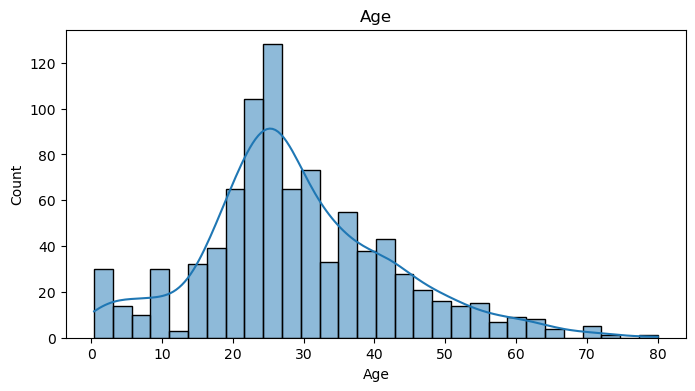

Survived
0    549
1    342
Name: count, dtype: int64
Pclass
3    491
1    216
2    184
Name: count, dtype: int64
Sex
0    577
1    314
Name: count, dtype: int64
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# ستون‌های عددی
print(df.describe())

# توزیع Age
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age')
plt.show()

# ستون‌های categorical
print(df['Survived'].value_counts())
print(df['Pclass'].value_counts())
print(df['Sex'].value_counts())

# چک class imbalance — خیلی مهم!
print(df['Survived'].value_counts(normalize=True))
# 0    0.616  ← ۶۱٪ فوت کردن
# 1    0.384  ← ۳۸٪ زنده موندن
# این یعنی داده imbalanced است — مدل ممکنه bias داشته باشه

Bivariate

In [66]:
# drop_first=True chon ML midoone ke age s, q --> 0 bashan fagat c mimoone
# df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

# print(df.columns.tolist())
print(df[['Embarked_S', 'Embarked_Q']].head(8))
print(df.dtypes)

   Embarked_S  Embarked_Q
0        True       False
1       False       False
2        True       False
3        True       False
4        True       False
5       False        True
6        True       False
7        True       False
Survived         int64
Pclass           int64
Sex              int64
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Age_missing      int64
Has_Cabin        int64
Embarked_Q        bool
Embarked_S        bool
dtype: object


Sex
0    0.189
1    0.742
Name: Survived, dtype: float64
Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64


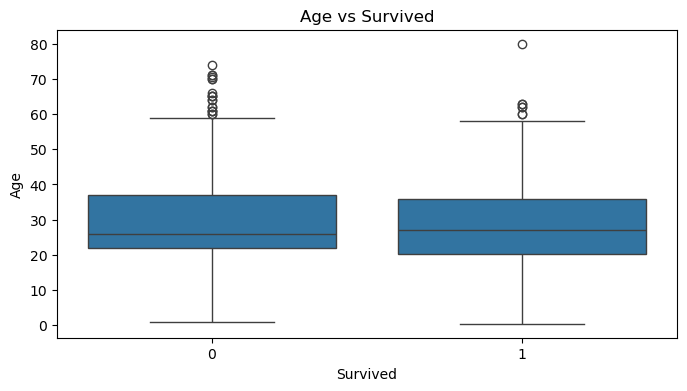

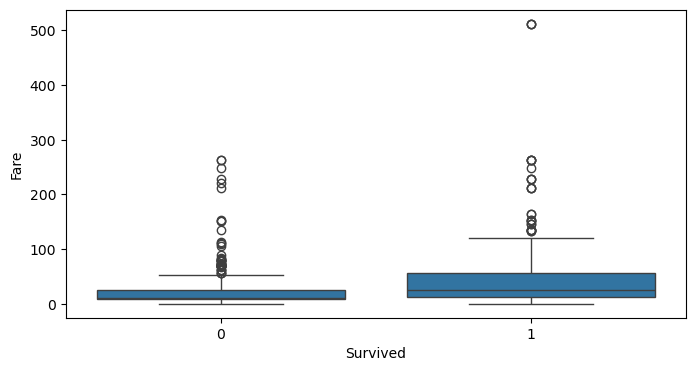

In [79]:
# Sex vs Survived
print(df.groupby('Sex')['Survived'].mean().round(3))
# female    0.742  ← زنان بیشتر زنده موندن
# male      0.189

# Pclass vs Survived
print(df.groupby('Pclass')['Survived'].mean().round(3))
# 1    0.630
# 2    0.473
# 3    0.242  ← درجه ۳ کمترین بقا

# Age vs Survived — با boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Age vs Survived')
plt.show()

# Fare vs Survived
plt.figure(figsize=(8, 4))
sns.boxplot(x='Survived', y='Fare', data=df)
plt.show()

Multivariate

Pclass      1      2      3
Sex                        
0       0.369  0.157  0.135
1       0.968  0.921  0.500


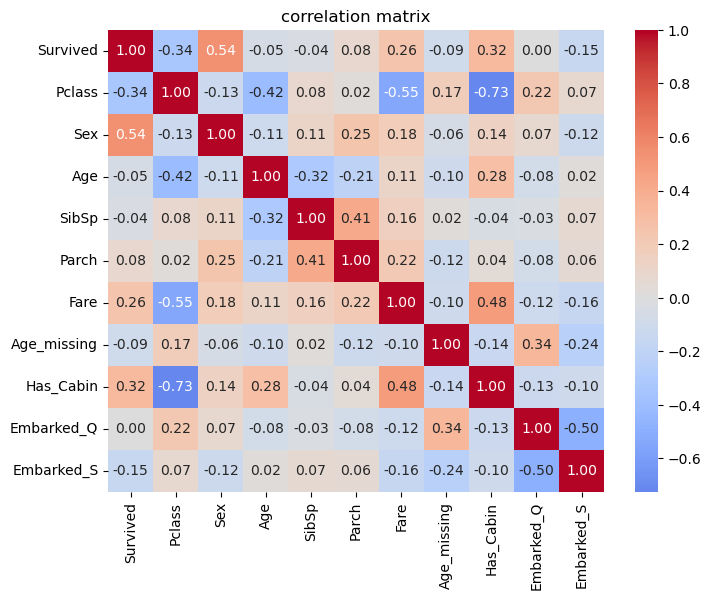

In [68]:
# Pclass + Sex + Survived با هم
pivot = df.pivot_table('Survived', index='Sex', columns='Pclass', aggfunc='mean')
print(pivot.round(3))
#        Pclass    1      2      3
# Sex
# female         0.968  0.921  0.500
# male           0.369  0.157  0.135

# هیت‌مپ همبستگی
plt.figure(figsize=(8, 6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('correlation matrix')
plt.show()

Outlier Detection
Outlier ≠ Error

Outlier detection is not about removing anomalies, it’s about understanding them.

In [69]:
# روش IQR
def find_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outlier — محدوده: [{lower:.1f}, {upper:.1f}]")
    return outliers

find_outliers('Age')
find_outliers('Fare')
find_outliers('SibSp')

# Fare رو بررسی کن
print(df['Fare'].sort_values(ascending=False).head(10))
# یه نفر 512 پرداخته! این outlier واقعیه یا خطا؟

Age: 33 outlier — محدوده: [-0.2, 57.8]
Fare: 116 outlier — محدوده: [-26.7, 65.6]
SibSp: 46 outlier — محدوده: [-1.5, 2.5]
258    512.3292
737    512.3292
679    512.3292
88     263.0000
27     263.0000
341    263.0000
438    263.0000
311    262.3750
742    262.3750
118    247.5208
Name: Fare, dtype: float64


Feature Selection

In [70]:
# همبستگی با target
corr_with_target = df.corr(numeric_only=True)['Survived'].abs().sort_values(ascending=False)
print(corr_with_target)
# Survived      1.000
# Fare          0.257  ← رابطه متوسط
# Pclass        0.338  ← مهم
# Age           0.077  ← ضعیف
# Has_Cabin     0.316  ← مهم — خوب که نگه داشتیم!

Survived       1.000000
Sex            0.543351
Pclass         0.338481
Has_Cabin      0.316912
Fare           0.257307
Embarked_S     0.149683
Age_missing    0.092197
Parch          0.081629
Age            0.053834
SibSp          0.035322
Embarked_Q     0.003650
Name: Survived, dtype: float64


Age — Normal Distribution ---> standardscaler

Mean:     29.02
Median:   26.00
Skewness: 0.476
Kurtosis: 0.536

Shapiro-Wilk: stat=0.9741, p=0.0000
Not perfectly normal


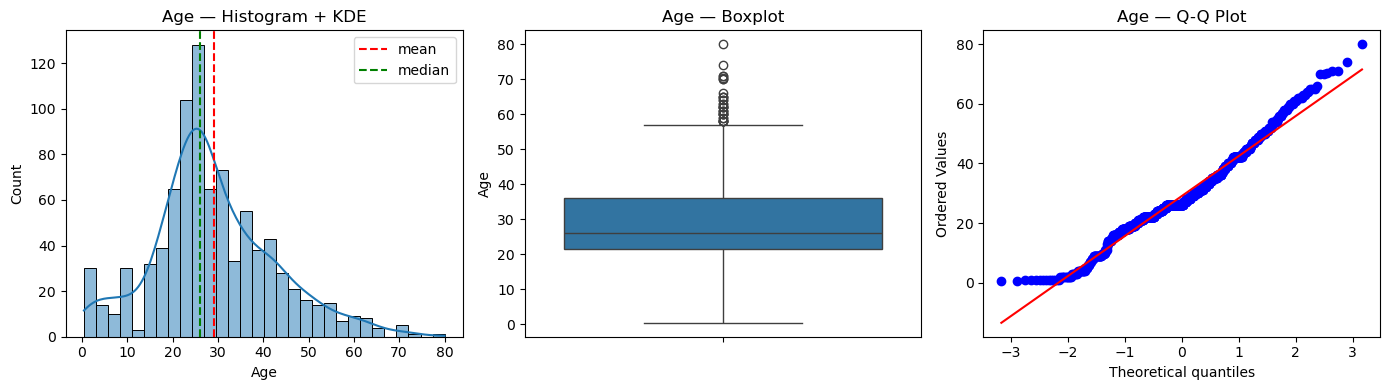

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- check skewness and kurtosis ---
print(f"Mean:     {df['Age'].mean():.2f}")
print(f"Median:   {df['Age'].median():.2f}")
print(f"Skewness: {df['Age'].skew():.3f}")   # close to 0 = normal
print(f"Kurtosis: {df['Age'].kurt():.3f}")   # close to 0 = normal

# --- formal normality test ---
stat, p = stats.shapiro(df['Age'].dropna())
print(f"\nShapiro-Wilk: stat={stat:.4f}, p={p:.4f}")
print("Normal" if p > 0.05 else "Not perfectly normal")

# --- visual check ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# histogram + KDE
sns.histplot(df['Age'], kde=True, ax=axes[0], bins=30)
axes[0].axvline(df['Age'].mean(),   color='red',   linestyle='--', label='mean')
axes[0].axvline(df['Age'].median(), color='green', linestyle='--', label='median')
axes[0].legend()
axes[0].set_title('Age — Histogram + KDE')

# boxplot — shows outliers
sns.boxplot(y=df['Age'], ax=axes[1])
axes[1].set_title('Age — Boxplot')

# Q-Q plot — if points follow diagonal line = normal
stats.probplot(df['Age'].dropna(), dist="norm", plot=axes[2])
axes[2].set_title('Age — Q-Q Plot')

plt.tight_layout()
plt.show()

Fare — Right-Skewed --->

Mean:     32.20
Median:   14.45
Skewness: 4.787
Kurtosis: 33.398
(-0.513, 102.466]     838
(102.466, 204.932]     33
(204.932, 307.398]     17
(409.863, 512.329]      3
(307.398, 409.863]      0
Name: count, dtype: int64


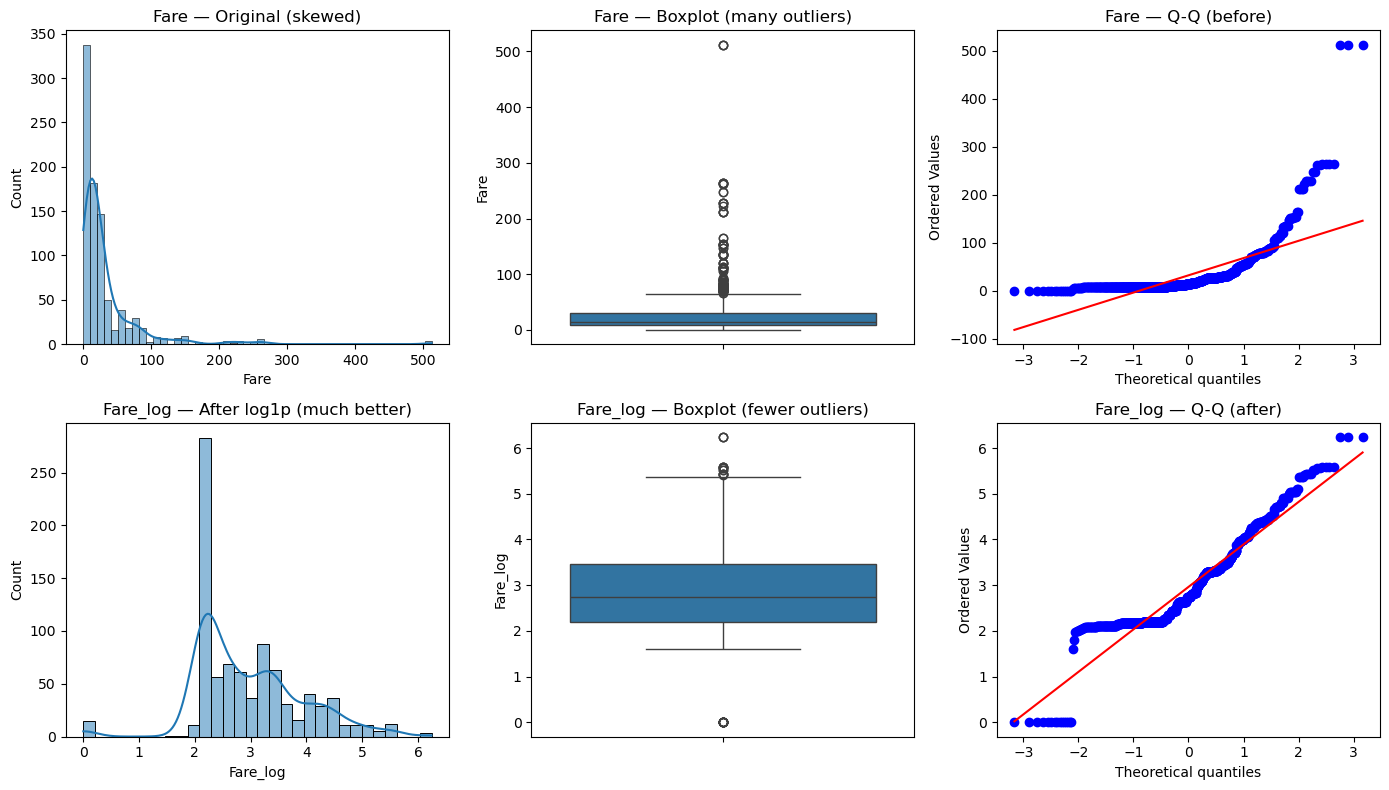


Skewness before: 4.787
Skewness after:  0.395


In [72]:
print(f"Mean:     {df['Fare'].mean():.2f}")
print(f"Median:   {df['Fare'].median():.2f}")
print(f"Skewness: {df['Fare'].skew():.3f}")   # ~4.4 — heavily right-skewed
print(f"Kurtosis: {df['Fare'].kurt():.3f}")   # very high — heavy tail

print(df['Fare'].value_counts(bins=5))
# (0, 102]     → 832 passengers  ← vast majority
# (102, 205]   → 37  passengers
# (205, 307]   → 10  passengers
# (307, 410]   → 5   passengers
# (410, 512]   → 7   passengers  ← tiny minority with huge fares

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# --- before transformation ---
sns.histplot(df['Fare'], kde=True, ax=axes[0, 0], bins=50)
axes[0, 0].set_title('Fare — Original (skewed)')

sns.boxplot(y=df['Fare'], ax=axes[0, 1])
axes[0, 1].set_title('Fare — Boxplot (many outliers)')

stats.probplot(df['Fare'], dist="norm", plot=axes[0, 2])
axes[0, 2].set_title('Fare — Q-Q (before)')

# --- after log transformation ---
# +1 to avoid log(0) if Fare=0 exists
df['Fare_log'] = np.log1p(df['Fare'])

sns.histplot(df['Fare_log'], kde=True, ax=axes[1, 0], bins=30)
axes[1, 0].set_title('Fare_log — After log1p (much better)')

sns.boxplot(y=df['Fare_log'], ax=axes[1, 1])
axes[1, 1].set_title('Fare_log — Boxplot (fewer outliers)')

stats.probplot(df['Fare_log'], dist="norm", plot=axes[1, 2])
axes[1, 2].set_title('Fare_log — Q-Q (after)')

plt.tight_layout()
plt.show()

print(f"\nSkewness before: {df['Fare'].skew():.3f}")
print(f"Skewness after:  {df['Fare_log'].skew():.3f}")  # much closer to 0

Survived — Bernoulli Distribution

[0 1]
Survived
0    549
1    342
Name: count, dtype: int64
P(survived): 0.384
P(survived=1): 0.384
P(survived=0): 0.616

Class balance:
Survived
0    549
1    342
Name: count, dtype: int64


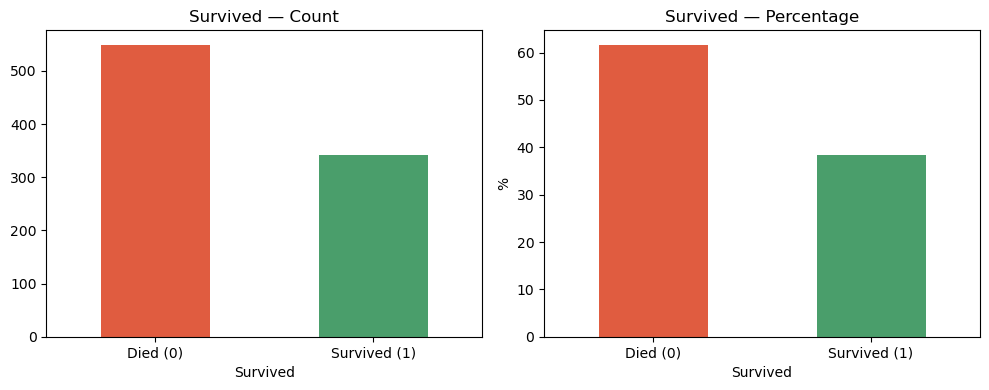


Imbalance ratio: 1.61:1


In [73]:
print(df['Survived'].unique())          # [0, 1] — only two values
print(df['Survived'].value_counts())
# 0    549  (died)
# 1    342  (survived)

print(f"P(survived): {df['Survived'].mean():.3f}")  # ~0.38
# Bernoulli: only 0 and 1, one trial
counts = df['Survived'].value_counts()
p_success = df['Survived'].mean()

print(f"P(survived=1): {p_success:.3f}")
print(f"P(survived=0): {1-p_success:.3f}")
print(f"\nClass balance:\n{counts}")

# --- bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts.plot(kind='bar', ax=axes[0], color=['#E05C40', '#4A9E6B'])
axes[0].set_title('Survived — Count')
axes[0].set_xticklabels(['Died (0)', 'Survived (1)'], rotation=0)

# class imbalance check
(counts / len(df) * 100).plot(kind='bar', ax=axes[1], color=['#E05C40', '#4A9E6B'])
axes[1].set_title('Survived — Percentage')
axes[1].set_xticklabels(['Died (0)', 'Survived (1)'], rotation=0)
axes[1].set_ylabel('%')

plt.tight_layout()
plt.show()

# imbalance ratio
ratio = counts[0] / counts[1]
print(f"\nImbalance ratio: {ratio:.2f}:1")
# if > 3:1 → serious imbalance, need SMOTE or class_weight

Pclass — Ordinal Distribution

Pclass
1    216
2    184
3    491
Name: count, dtype: int64

Survival rate:
Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64


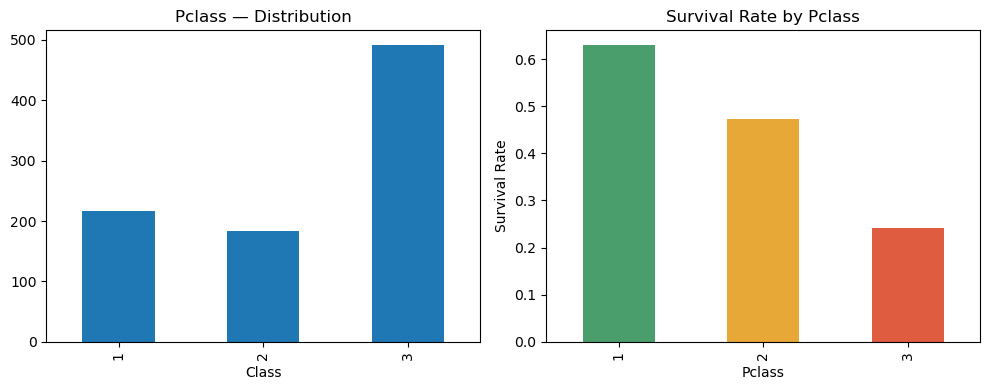

In [74]:
# Ordinal: finite ordered categories (1 > 2 > 3 in terms of quality)
counts = df['Pclass'].value_counts().sort_index()
print(counts)

# survival rate per class
survival_by_class = df.groupby('Pclass')['Survived'].mean()
print(f"\nSurvival rate:\n{survival_by_class.round(3)}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts.plot(kind='bar', ax=axes[0])
axes[0].set_title('Pclass — Distribution')
axes[0].set_xlabel('Class')

survival_by_class.plot(kind='bar', ax=axes[1], color=['#4A9E6B', '#E8A838', '#E05C40'])
axes[1].set_title('Survival Rate by Pclass')
axes[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

SibSp و Parch — Poisson-like Distribution


SibSp:
  mean:     0.523
  variance: 1.216
  skewness: 3.695
  min: 0, max: 8

Parch:
  mean:     0.382
  variance: 0.650
  skewness: 2.749
  min: 0, max: 6
SibSp
0    608
1    209
2     28
3     16
4     18
5      5
8      7
Name: count, dtype: int64

SibSp:
  mean (lambda): 0.523
  variance:      1.216
  mean≈var? No — overdispersed
  skewness: 3.695

Parch:
  mean (lambda): 0.382
  variance:      0.650
  mean≈var? Yes
  skewness: 2.749


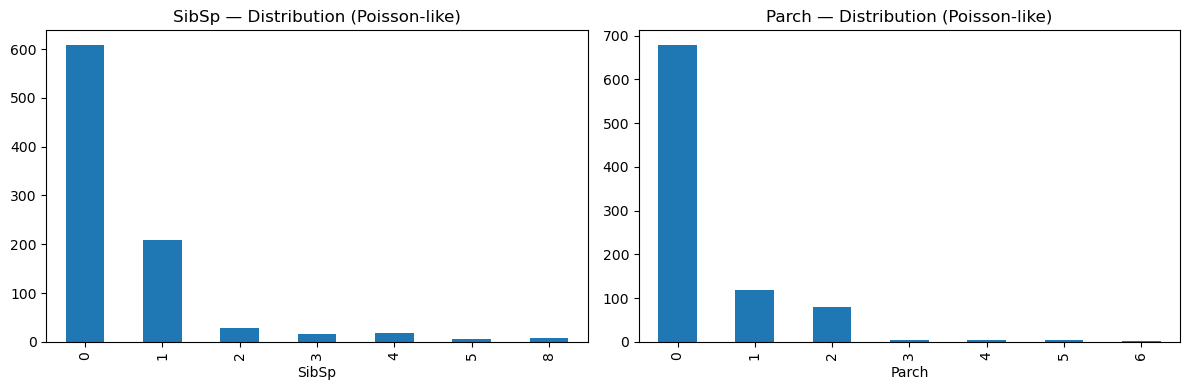


SibSp=0: 68.2%
Parch=0: 76.1%


In [75]:
for col in ['SibSp', 'Parch']:
    mean = df[col].mean()
    var  = df[col].var()
    print(f"\n{col}:")
    print(f"  mean:     {mean:.3f}")
    print(f"  variance: {var:.3f}")
    print(f"  skewness: {df[col].skew():.3f}")
    print(f"  min: {df[col].min()}, max: {df[col].max()}")

# SibSp: mean≈0.52, var≈1.1, skew≈3.7 — count data starting at 0
# Parch: mean≈0.38, var≈0.65, skew≈3.8 — count data starting at 0


print(df['SibSp'].value_counts().sort_index())
# 0    608   ← most traveled alone
# 1    209
# 2     28
# 3     16
# 4     18
# 5      5
# 8      7   ← rare large families — overdispersed


# Poisson: count data — number of occurrences, starts at 0
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ['SibSp', 'Parch']):
    counts = df[col].value_counts().sort_index()
    counts.plot(kind='bar', ax=ax)

    # fit Poisson
    lam = df[col].mean()   # lambda = mean for Poisson
    print(f"\n{col}:")
    print(f"  mean (lambda): {lam:.3f}")
    print(f"  variance:      {df[col].var():.3f}")
    # for true Poisson: mean ≈ variance
    print(f"  mean≈var? {'Yes' if abs(lam - df[col].var()) < 0.5 else 'No — overdispersed'}")
    print(f"  skewness: {df[col].skew():.3f}")

    ax.set_title(f'{col} — Distribution (Poisson-like)')
    ax.set_xlabel(col)

plt.tight_layout()
plt.show()

# most passengers traveled alone or with very few family members
print(f"\nSibSp=0: {(df['SibSp']==0).mean()*100:.1f}%")
print(f"Parch=0: {(df['Parch']==0).mean()*100:.1f}%")

Sex , Embarked — Categorical / Nominal

[0 1]
[ True False]
[False  True]

Sex:
Sex
0    577
1    314
Name: count, dtype: int64
entropy: 0.649

Embarked_S:
Embarked_S
True     646
False    245
Name: count, dtype: int64
entropy: 0.588

Embarked_Q:
Embarked_Q
False    814
True      77
Name: count, dtype: int64
entropy: 0.294


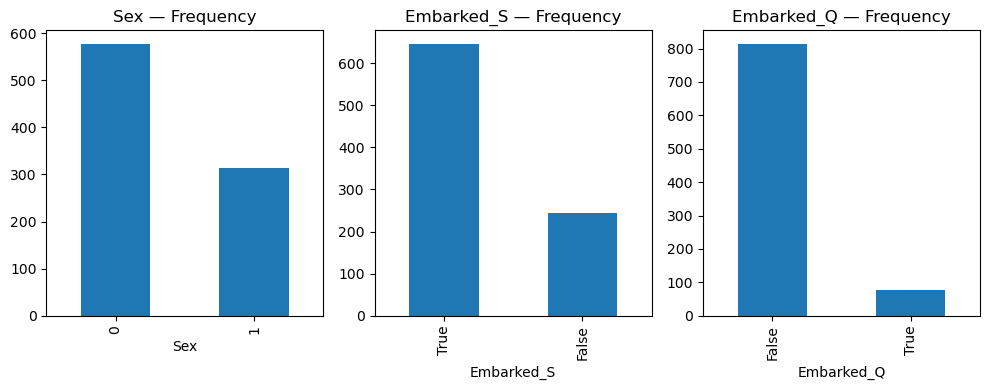

In [76]:
print(df['Sex'].unique())       # ['male', 'female'] — no order
print(df['Embarked_S'].unique())  # ['S', 'C', 'Q']   — no order
print(df['Embarked_Q'].unique())  # ['S', 'C', 'Q']   — no order

# is Southampton "greater than" Cherbourg? NO
# is male "greater than" female? NO
# → pure categories with no mathematical relationship

fig, axes = plt.subplots(1, 3, figsize=(10, 4))

for ax, col in zip(axes, ['Sex', 'Embarked_S', 'Embarked_Q']):
    counts = df[col].value_counts()
    counts.plot(kind='bar', ax=ax)
    ax.set_title(f'{col} — Frequency')
    ax.set_xlabel(col)
    print(f"\n{col}:")
    print(counts)
    print(f"entropy: {stats.entropy(counts):.3f}")
    # high entropy = more balanced = more informative

plt.tight_layout()
plt.show()